# Toy Model: Analysis

In [14]:
sup_method='moekratter' # options: 'simple', 'moekratter', '50', 'snow  '

from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
from scipy import stats
import scipy


# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
# enable math fonts
mpl.rc('mathtext', default = 'regular')
plt.rcParams['savefig.dpi'] = 400 

import seaborn as sns 

from sbin.SuppressionSimulator import SuppressionSimulator
from sbin.simulation_helper import run_trials
from sbin.plotting_utilities import plot_hist_confidence, plot_ecdf_confidence, ecdf_grid
from sbin.complexity import create_complexity_df
from sbin.statistics_utilities import *


if sup_method=='simple':
    from sbin.suppression_utilities import suppression_factor_simple as my_suppression_factor
elif sup_method=='moekratter':
    from sbin.suppression_utilities import suppression_factor_mk21 as my_suppression_factor
elif sup_method=='50':
    from sbin.suppression_utilities import suppression_factor_50 as my_suppression_factor  
elif sup_method=='snow':
    from sbin.suppression_utilities import suppression_factor_snow as my_suppression_factor
else:
    raise

teff_limit = (4700, 6500)
teff_limit = None


In [ ]:
import builtins
import atexit

log_file = open('toy_model.log', 'a')
_builtin_print = builtins.print

def print(*args, **kwargs):
    _builtin_print(*args, **kwargs)
    log_kwargs = kwargs.copy()
    log_kwargs['file'] = log_file
    _builtin_print(*args, **log_kwargs)
    log_file.flush()


print("===========================================")
print("Running toy model with... \n suppression method: " + sup_method + "\n teff limit: " + str(teff_limit))



Running toy model with... 
 suppression method: moekratter, teff limit: None


### Read in data saved from Filtering

In [16]:
with open("filtered_data.pkl", "rb") as f:
     data = pickle.load(f)
          
# conjoined list of binaries
binaries = data["binaries_filtered"]

allbinaries = data["binaries_unfiltered"]

# separation values (one per KOI) for each binary
binary_separations = binaries.groupby('KOI')['SepAU'].first().values
allbinaries_separations = allbinaries.groupby('KOI')['SepAU'].first().values

# all KOIs that are presumed single
singles = data["kois_filtered_cc"]

if teff_limit is not None:
    binaries = binaries[ (binaries['steff_adopt']>teff_limit[0]) & (binaries['steff_adopt']<teff_limit[1]) ]
    singles = singles[ (singles['koi_steff']>teff_limit[0]) & (singles['koi_steff']<teff_limit[1]) ]
    tflag = str(teff_limit[0]) + "-" + str(teff_limit[1]) + "K"
else:
    tflag = "allTeff"

In [ ]:
print("\nBASIC INFO:")
print(f"There are {len(binaries)} planets in binaries and {len(singles)} single KOIs in the sample")
print(f"There are {len(binaries[binaries['SepAU']<100])} planets in binaries with separation < 100 AU")
print(f"There are {len(binary_separations)} systems in binaries")
print(f"There are {len(binary_separations[binary_separations<100])} systems in binaries with separation < 100 AU")


 BASIC INFO:
There are 202 planets in binaries and 699 single KOIs in the sample
There are 63 planets in binaries with separation < 100 AU
There are 132 systems in binaries
There are 38 systems in binaries with separation < 100 AU


# Toy Model

### Suppress the KOIs

In [18]:

# ------------------------------------------------------------------
#  Initialise the simulator
# ------------------------------------------------------------------
KeplerSimulator = SuppressionSimulator(
    planets_cat=singles,
    sup_function=my_suppression_factor,
    join_col="KOI",
    prad_col="koi_prad",
    teff_col="koi_steff",
    random_state=42,             
)

# ------------------------------------------------------------------
#  Run it
# ------------------------------------------------------------------
max_a_draw = 100.
ntrials = 1000
res_systems, res_planets  = run_trials(
    simulator=KeplerSimulator,
    n_trials=ntrials,
    max_a_draw=max_a_draw)

print(f"Simulated {ntrials} trials with maximum a draw of {max_a_draw} AU")
print("Simulated number of systems (planets suppressed): " + str(len(res_planets.survived_systems['a_values'])))
print("Simulated number of systems (systems suppressed): " + str(len(res_systems.survived_systems['a_values'])))


Simulated 1000 trials with maximum a draw of 100.0 AU
Simulated number of systems (planets suppressed): 174887
Simulated number of systems (systems suppressed): 146449


## Semi-major axis plots

a-values P-value (planets suppressed vs binaries)=38):
 KstestResult(statistic=0.11474175956625227, pvalue=0.6568838278474602, statistic_location=15.89697340028802, statistic_sign=-1)
a-values P-value (systems suppressed vs binaries)=38):
 KstestResult(statistic=0.08737728348758739, pvalue=0.9094510525926253, statistic_location=15.896602194057749, statistic_sign=-1)


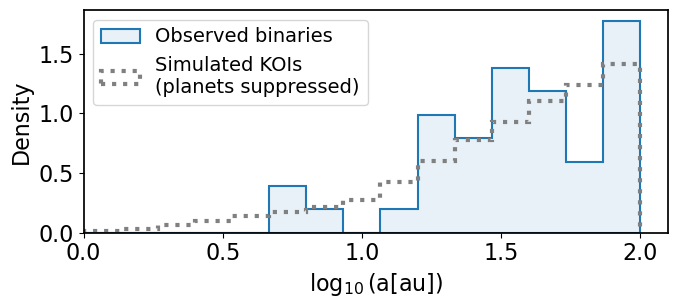

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
log_min, log_max = 0., np.log10(max_a_draw)              
n_bins = 15                             
bins   = np.linspace(log_min, log_max, n_bins + 1)   # bin edges

ax.set_xlabel(r'$\log_{10}(a [au])$')
ax.set_ylabel('Density')

sim = res_systems.survived_systems['a_values']
plt.hist(np.log10(sim), bins=bins,
         histtype='step', density=True, ls=':',
         color='gray',  lw=3, label='Simulated KOIs\n(planets suppressed)')


obs = binary_separations[binary_separations<max_a_draw]
obs2 = allbinaries_separations[allbinaries_separations<max_a_draw]
plt.hist(np.log10(obs), bins=bins, 
         density=True, histtype='stepfilled', ls='-',
         edgecolor='C0', facecolor='#e8f1f7', 
         alpha=1, lw=1.5, label='Observed binaries')


handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(handles[::-1], labels[::-1], loc='upper left')
plt.xlim(log_min, log_max+0.1)
plt.tight_layout()

print("\nSEPARATION TEST:")

print("a-values P-value (planets suppressed vs binaries)=" + str(len(obs)) + "):\n", stats.ks_2samp(obs, res_planets.survived_systems['a_values']))
print("a-values P-value (systems suppressed vs binaries)=" + str(len(obs)) + "):\n", stats.ks_2samp(obs, res_systems.survived_systems['a_values']))



plt.savefig("separation_test_"+tflag+".png")

## Multiplicity plots

Close binary multiplicity: [0.63157895 0.21052632 0.07894737 0.02631579 0.05263158]
Wide binary multiplicity: [0.68918919 0.16216216 0.10810811 0.         0.04054054]
Systems suppressed simulated multiplicity: [0.70226495 0.19233317 0.06847435 0.02261538 0.01431215]
Planets suppressed simulated multiplicity: [0.82536152 0.13519587 0.03035674 0.00758204 0.00150383]
chi2 for multiplicity (systems suppressed): 0.5144829419769588
chi2 for multiplicity (planets suppressed): 0.0002202357295169183


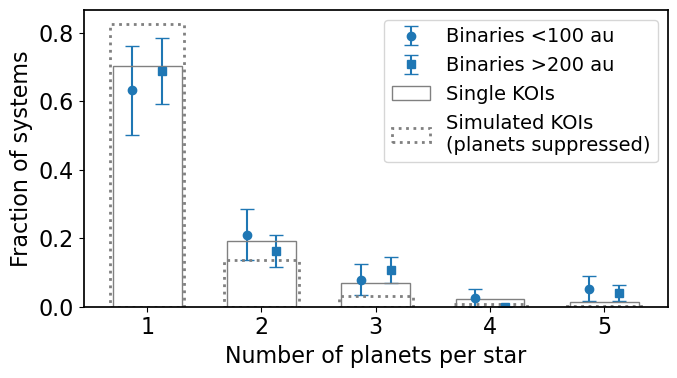

In [ ]:

bin_label = 'Binaries <100 au'
bin_col = 'C0'
koi_label = 'Single KOIs'
close = binaries['SepAU']<100.
    
print("\nRESULTS - MULTIPLICITY:")

def plot_multiplicity_hist(planet_counts, norm_to=True, offset=0, plot_error=False, **kwargs):
    nstars = len(planet_counts)
    if norm_to:
        ww = norm_to/nstars
    else:
        ww = 1. / nstars

    y, _ = np.histogram(planet_counts['n_planets'], 
                        bins=[0.5,1.5,2.5,3.5,4.5,5.5])
    if plot_error == False:
        ax.bar(x + offset, y/nstars, **kwargs)

    if plot_error:
        ax.errorbar(x + offset, y/nstars, yerr=np.sqrt(y)/nstars, 
                    fmt=kwargs.get('fmt','o'), 
                    color=kwargs.get('edgecolor','C0'), 
                    capsize=5, elinewidth=1.5,
                    zorder=1, label=kwargs.get('label', None))
        
    return(y/nstars)



fig, ax = plt.subplots(1, 1, figsize=(7,4), sharex=True, sharey=True)
x = np.array([1,2,3,4,5])

## the binaries

bin_planet_counts = binaries[close].groupby('KOI').size().reset_index(name='n_planets')
y = plot_multiplicity_hist(bin_planet_counts, 
                        norm_to=False, plot_error=True, offset=-0.13,
                        edgecolor=bin_col, facecolor='#e8f1f7', alpha=1, 
                        width=0.9, linewidth=1.5,
                        label=bin_label, fmt='o')
print(f"Close binary multiplicity: {y}")

wide = binaries['SepAU']>200.
wide_planet_counts = binaries[wide].groupby('KOI').size().reset_index(name='n_planets')
y = plot_multiplicity_hist(wide_planet_counts, 
                        norm_to=False, plot_error=True, offset=0.13, #len(bin_planet_counts),
                        edgecolor=bin_col, facecolor='None', alpha=1, 
                        width=0.9, linewidth=1.5, ls='--', fmt='s',
                        label='Binaries >200 au')
print(f"Wide binary multiplicity: {y}")

y = plot_multiplicity_hist(res_systems.survived_systems, 
                        norm_to=False, #len(bin_planet_counts),
                        #offset=-0.2,
                        ls='-', edgecolor='gray', facecolor='None',  
                        width=0.6, lw=1, label=koi_label)
print(f"Systems suppressed simulated multiplicity: {y}")

y =plot_multiplicity_hist(res_planets.survived_systems, 
                        norm_to=False, #len(bin_planet_counts),
                        #offset=0.2,
                        ls=':', edgecolor='gray', facecolor='none',  
                        width=0.65, lw=2,
                        label='Simulated KOIs \n(planets suppressed)')
print(f"Planets suppressed simulated multiplicity: {y}")

plt.xlabel('Number of planets per star')
plt.ylabel('Fraction of systems')
plt.legend()
#plt.ylim(0,0.9)
plt.tight_layout()

plt.savefig(f'plots/multiplicity_{sup_method}_{tflag}.png')



p_chi2_systems = chisquare_multiplicity(bin_planet_counts, res_systems.survived_systems)
p_chi2_planets = chisquare_multiplicity(bin_planet_counts, res_planets.survived_systems)
print("chi2 for multiplicity (systems suppressed):", p_chi2_systems)
print("chi2 for multiplicity (planets suppressed):", p_chi2_planets)



## Complexity


RESULTS - COMPLEXITY:
Close binaries with >2 planets 6
Wide binaries with >2 planets 11
Complexity KS P-value (planets suppressed, N multis=6898): KstestResult(statistic=0.27099642408427566, pvalue=0.6814607801503174, statistic_location=0.0762941618097414, statistic_sign=1)
Complexity KS P-value (systems suppressed, N multis=15436): KstestResult(statistic=0.3659194955515246, pvalue=0.31666900501781015, statistic_location=0.07153942672762093, statistic_sign=1)


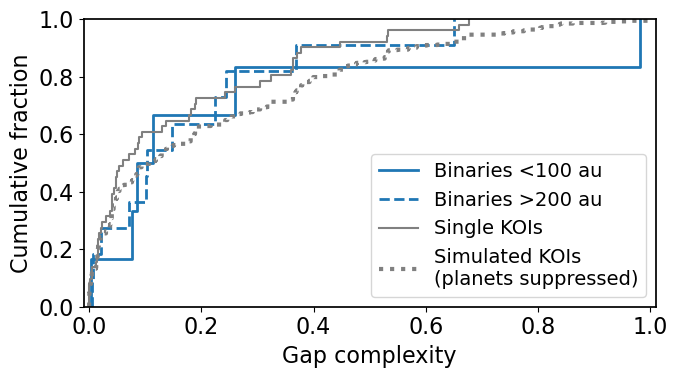

In [23]:
koi_df = create_complexity_df(singles)
koi_complexity = koi_df[koi_df['n_planets']>2]['gap_complexity'].values

print("\nRESULTS - COMPLEXITY:")

def complexity_helper(sample, just_need_n=False, **kwargs):
    df = create_complexity_df(sample)
    complexity = df[np.isfinite(df['gap_complexity'])]['gap_complexity'].values
    if just_need_n:
        return len(complexity)
    
    sns.ecdfplot(complexity, **kwargs)

    return(complexity)

col = 'C0'
    
fig, ax = plt.subplots(figsize=(7, 4))

close_complexity = complexity_helper(binaries[binaries['SepAU']<100.], 
                  ax=ax, label='Binaries <100 au', linewidth=2, color=col)
print("Close binaries with >2 planets", len(close_complexity))  

wide_complexity = complexity_helper(binaries[binaries['SepAU']>=200.], 
                  ax=ax, label='Binaries >200 au', linewidth=2, ls='--',color=col)
print("Wide binaries with >2 planets", len(wide_complexity))  


sns.ecdfplot(koi_complexity, ax=ax,
             label='Single KOIs', color='gray')

plt.xlabel('Cumulative Fraction')
plt.ylabel('Complexity')

n_to_sample = complexity_helper(binaries[binaries['SepAU']<100.], just_need_n=True)

def complexity_sampler(res):

    samples = []
    for trial in res.survived_periods:
        df = create_complexity_df(trial)
        sample = df[np.isfinite(df['gap_complexity'])]['gap_complexity'].values

        samples =np.concatenate([samples, sample])

    return np.asarray(samples).flatten()

samples = complexity_sampler(res_planets)
print("Complexity KS P-value (planets suppressed, N multis=" + str(len(samples)) + "):", stats.ks_2samp(samples, close_complexity))
sns.ecdfplot(samples, ax=ax,
             label='Simulated KOIs \n(planets suppressed)', 
             color='gray', ls=':', lw=3)

samples = complexity_sampler(res_systems)
print("Complexity KS P-value (systems suppressed, N multis=" + str(len(samples)) + "):", stats.ks_2samp(samples, close_complexity))

plt.legend()
plt.xlim(-0.01,1.01)
plt.ylim(0,1)
plt.xlabel('Gap complexity')
plt.ylabel('Cumulative fraction')
                     
# and the appropriate stats

plt.tight_layout()
plt.savefig(f'plots/complexity_{sup_method}_{tflag}.png')

In [22]:
print("===========================================\n")
atexit.register(log_file.close)

<function TextIOWrapper.close()>